# Pooled Mini-Batch: SIGReg vs W1 vs W2 (no RMS)

Compares three regularizers in the pooled 2-step setting:
- **SIGReg**: characteristic function test (cos/sin at quadrature knots)
- **Sliced W1**: sort + absolute difference to N(0,1) quantiles
- **Sliced W2 (squared)**: sort + squared difference (no sqrt)

Setup follows `scripts/demo_accumulated_w1.py`:
1. Warmup all methods from the same checkpoint (small batch W1)
2. Compare pooled 2-step for each loss type

In [1]:
import copy, os, sys, time, math
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

sys.path.insert(0, os.path.abspath('..'))
from src.accumulated_w1 import (
    AccumulatedSlicedLoss, SlicedW1Loss, SIGRegLoss,
    DeepMLP, generate_data, make_fixed_projection, eval_w1, evaluate_full,
)
from src.accumulated_w1.losses import _random_unit_directions, _gaussian_quantiles
from module import SIGReg

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

Device: cuda


In [2]:
# Config (matches demo_accumulated_w1.py)
D = 4                    # embedding dimension
K = 1024                 # dataset size
BS = 8                   # mini-batch size
PROJ_DIM = 32            # fixed projection dimension
NUM_PROJ = 256           # projection directions for loss
T = 8                    # accumulation steps (total forward passes per update)
WARMUP_STEPS = 20000     # warmup updates (shared, plain W1 BS=8)
FINETUNE_STEPS = 20000   # comparison phase updates
LR = 1e-3
EVAL_EVERY = 200
DISTRIBUTIONS = ['blobs', 'diagonal_cross']

## W2-squared loss (no RMS)

In [3]:
class SlicedW2SquaredLoss(nn.Module):
    """Sliced W2-squared: mean squared difference (no sqrt per projection)."""
    def __init__(self, num_proj=1024):
        super().__init__()
        self.num_proj = num_proj

    def forward(self, x):
        B, D = x.shape[-2], x.shape[-1]
        A = _random_unit_directions(D, self.num_proj, x.device, x.dtype)
        proj_sorted = torch.sort(x @ A, dim=-2).values
        ref = _gaussian_quantiles(B, x.device, x.dtype)
        ref = ref.reshape(*([1] * (proj_sorted.dim() - 2)), B, 1)
        return ((proj_sorted - ref) ** 2).mean()

## Training functions

In [4]:
def run_pooled(mlp_state, projected, loss_mode, steps, eval_every):
    """Pooled 2-step: T-1 no-grad passes + 1 grad pass."""
    mlp = DeepMLP(PROJ_DIM, 128, D, depth=2).to(device)
    mlp.load_state_dict(copy.deepcopy(mlp_state))
    opt = torch.optim.Adam(mlp.parameters(), lr=LR)

    # Build loss function
    if loss_mode == 'w1':
        loss_fn = SlicedW1Loss(num_proj=NUM_PROJ).to(device)
    elif loss_mode == 'w2sq':
        loss_fn = SlicedW2SquaredLoss(num_proj=NUM_PROJ).to(device)
    elif loss_mode == 'sigreg':
        loss_fn = SIGRegLoss(num_proj=NUM_PROJ).to(device)

    # Build accumulator
    if loss_mode == 'sigreg':
        sigreg_mod = SIGReg(knots=17, num_proj=NUM_PROJ).to(device)
        accum = AccumulatedSlicedLoss(
            accum_steps=T - 1, num_proj=NUM_PROJ,
            mode='sigreg', sigreg=sigreg_mod)
    else:
        # For w2sq, we do manual pooling (AccumulatedSlicedLoss
        # uses sqrt for w2 mode, so we compute manually)
        accum = None

    history = []
    proj_data = projected.to(device)

    for step in range(1, steps + 1):
        mlp.train()

        if loss_mode == 'sigreg':
            # Use AccumulatedSlicedLoss for SIGReg
            with torch.no_grad():
                for _ in range(T - 1):
                    idx = torch.randint(0, K, (BS,), device=device)
                    accum.accum_step(mlp(proj_data[idx]))
            idx = torch.randint(0, K, (BS,), device=device)
            loss = accum.grad_step(mlp(proj_data[idx]))
        else:
            # Manual pooling for W1 and W2-squared
            detached = []
            with torch.no_grad():
                for _ in range(T - 1):
                    idx = torch.randint(0, K, (BS,), device=device)
                    detached.append(mlp(proj_data[idx]).detach())
            idx = torch.randint(0, K, (BS,), device=device)
            live = mlp(proj_data[idx])
            all_emb = torch.cat([live] + detached, dim=0)

            n_total = all_emb.shape[0]
            A = _random_unit_directions(D, NUM_PROJ, device, all_emb.dtype)
            proj_sorted = torch.sort(all_emb @ A, dim=0).values
            ref = _gaussian_quantiles(n_total, device, all_emb.dtype).unsqueeze(1)

            if loss_mode == 'w1':
                loss = (proj_sorted - ref).abs().mean()
            else:  # w2sq
                loss = ((proj_sorted - ref) ** 2).mean()

            # Gradient dilution compensation
            loss = loss * (n_total / BS)

        opt.zero_grad()
        loss.backward()
        opt.step()

        if step % eval_every == 0:
            mlp.eval()
            with torch.no_grad():
                history.append((step, eval_w1(mlp(proj_data).cpu().numpy())))

    mlp.eval()
    with torch.no_grad():
        final = mlp(proj_data).cpu().numpy()
    return history, final


def run_minibatch(mlp_state, projected, loss_mode, steps, eval_every):
    """Plain mini-batch (no pooling) for comparison."""
    mlp = DeepMLP(PROJ_DIM, 128, D, depth=2).to(device)
    mlp.load_state_dict(copy.deepcopy(mlp_state))
    opt = torch.optim.Adam(mlp.parameters(), lr=LR)

    if loss_mode == 'w1':
        loss_fn = SlicedW1Loss(num_proj=NUM_PROJ).to(device)
    elif loss_mode == 'w2sq':
        loss_fn = SlicedW2SquaredLoss(num_proj=NUM_PROJ).to(device)
    elif loss_mode == 'sigreg':
        loss_fn = SIGRegLoss(num_proj=NUM_PROJ).to(device)

    history = []
    proj_data = projected.to(device)

    for step in range(1, steps + 1):
        mlp.train()
        idx = torch.randint(0, K, (BS,), device=device)
        loss = loss_fn(mlp(proj_data[idx]))
        opt.zero_grad()
        loss.backward()
        opt.step()

        if step % eval_every == 0:
            mlp.eval()
            with torch.no_grad():
                history.append((step, eval_w1(mlp(proj_data).cpu().numpy())))

    mlp.eval()
    with torch.no_grad():
        final = mlp(proj_data).cpu().numpy()
    return history, final

## Run experiments

In [5]:
all_results = {}

for dist_name in DISTRIBUTIONS:
    print(f'\n=== {dist_name} ===')

    # Generate data
    torch.manual_seed(42)
    data = generate_data(dist_name, K, D)
    W = make_fixed_projection(D, PROJ_DIM, seed=0).to(device)
    projected = data.to(device) @ W

    # Warmup (shared checkpoint, plain W1 BS=8)
    torch.manual_seed(123)
    mlp = DeepMLP(PROJ_DIM, 128, D, depth=2).to(device)
    opt = torch.optim.Adam(mlp.parameters(), lr=LR)
    loss_fn = SlicedW1Loss(num_proj=NUM_PROJ).to(device)
    warmup_hist = []

    print('  Warmup...', end=' ', flush=True)
    for step in range(1, WARMUP_STEPS + 1):
        mlp.train()
        idx = torch.randint(0, K, (BS,), device=device)
        loss = loss_fn(mlp(projected[idx]))
        opt.zero_grad()
        loss.backward()
        opt.step()
        if step % EVAL_EVERY == 0:
            mlp.eval()
            with torch.no_grad():
                warmup_hist.append((step, eval_w1(mlp(projected).cpu().numpy())))

    ckpt = copy.deepcopy(mlp.state_dict())
    print(f'W1={warmup_hist[-1][1]:.4f}')

    # Run all methods
    results = {}
    loss_modes = ['sigreg', 'w1', 'w2sq']
    loss_labels = {'sigreg': 'SIGReg', 'w1': 'Sliced W1', 'w2sq': 'Sliced W2-sq'}

    for loss_mode in loss_modes:
        # Mini-batch (no pooling)
        label = f'{loss_labels[loss_mode]} mini (BS={BS})'
        print(f'  {label}...', end=' ', flush=True)
        t0 = time.time()
        hist, final = run_minibatch(ckpt, projected, loss_mode,
                                     FINETUNE_STEPS, EVAL_EVERY)
        print(f'W1={hist[-1][1]:.4f}  time={time.time()-t0:.1f}s')
        results[label] = (hist, final)

        # Pooled 2-step
        label = f'{loss_labels[loss_mode]} pooled (T={T})'
        print(f'  {label}...', end=' ', flush=True)
        t0 = time.time()
        hist, final = run_pooled(ckpt, projected, loss_mode,
                                  FINETUNE_STEPS, EVAL_EVERY)
        print(f'W1={hist[-1][1]:.4f}  time={time.time()-t0:.1f}s')
        results[label] = (hist, final)

    all_results[dist_name] = (warmup_hist, results)


=== blobs ===
  Warmup... W1=0.1534
  SIGReg mini (BS=8)... W1=0.1443  time=16.4s
  SIGReg pooled (T=8)... W1=0.0745  time=25.4s
  Sliced W1 mini (BS=8)... W1=0.1535  time=14.1s
  Sliced W1 pooled (T=8)... W1=0.0867  time=23.0s
  Sliced W2-sq mini (BS=8)... W1=0.1015  time=14.4s
  Sliced W2-sq pooled (T=8)... W1=0.0751  time=23.7s

=== diagonal_cross ===
  Warmup... W1=0.1442
  SIGReg mini (BS=8)... W1=0.1161  time=16.4s
  SIGReg pooled (T=8)... W1=0.0665  time=26.2s
  Sliced W1 mini (BS=8)... W1=0.1231  time=14.4s
  Sliced W1 pooled (T=8)... W1=0.0877  time=24.3s
  Sliced W2-sq mini (BS=8)... W1=0.1216  time=14.8s
  Sliced W2-sq pooled (T=8)... W1=0.0847  time=23.1s


## Convergence plots

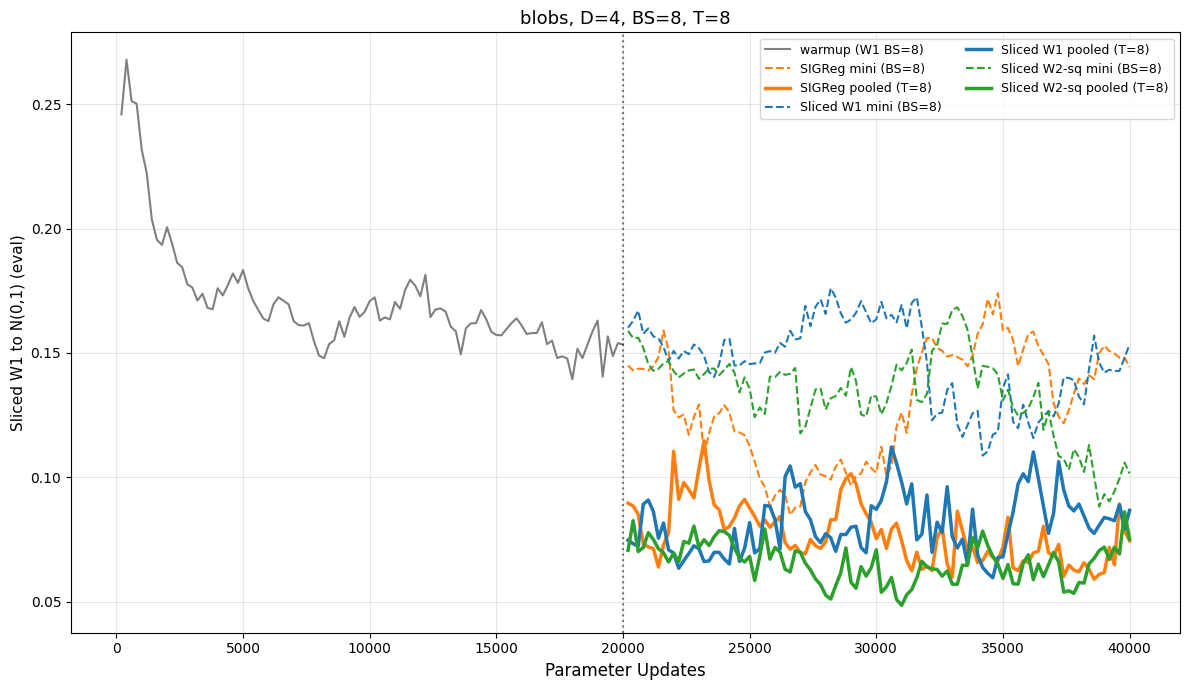

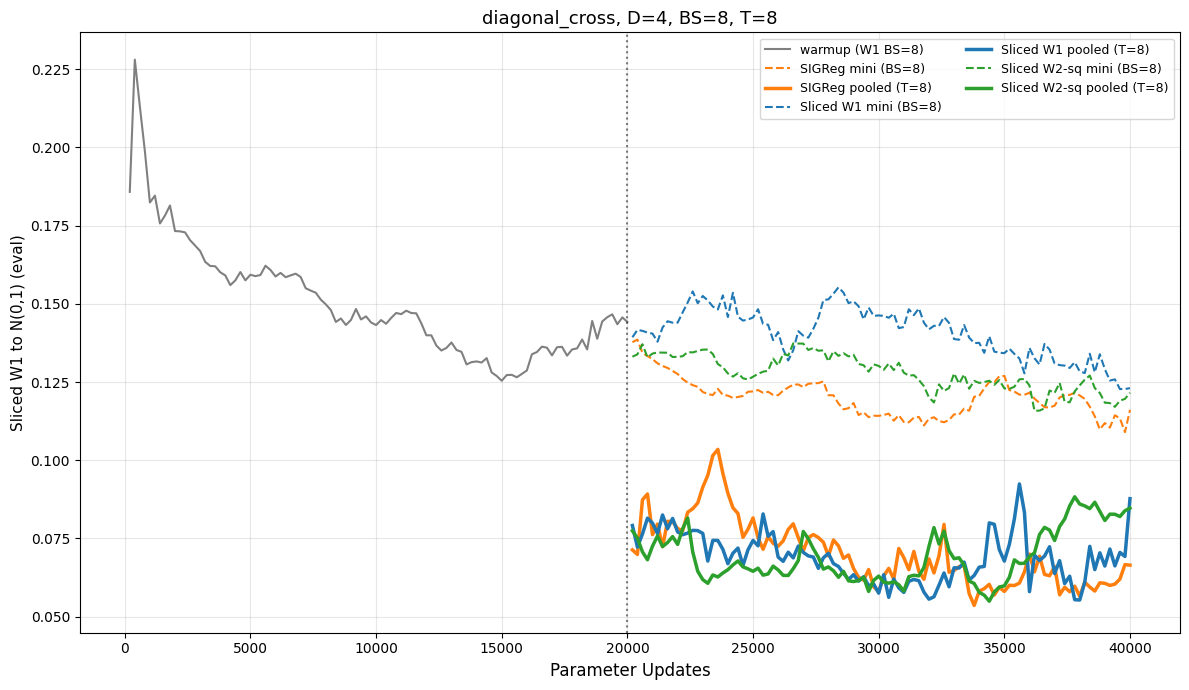

In [6]:
colors = {
    'SIGReg': 'tab:orange',
    'Sliced W1': 'tab:blue',
    'Sliced W2-sq': 'tab:green',
}

for dist_name in DISTRIBUTIONS:
    warmup_hist, results = all_results[dist_name]

    fig, ax = plt.subplots(figsize=(12, 7))

    # Warmup
    ws, wv = zip(*warmup_hist)
    ax.plot(ws, wv, color='grey', linewidth=1.5, label='warmup (W1 BS=8)')
    ax.axvline(WARMUP_STEPS, color='black', linestyle=':', alpha=0.5)

    # Methods
    for label, (hist, _) in results.items():
        hs, hv = zip(*hist)
        hs = [h + WARMUP_STEPS for h in hs]

        # Determine color and style from label
        for loss_name, c in colors.items():
            if loss_name in label:
                color = c
                break
        ls = '--' if 'mini' in label else '-'
        lw = 1.5 if 'mini' in label else 2.5

        ax.plot(hs, hv, color=color, linewidth=lw, linestyle=ls, label=label)

    ax.set_xlabel('Parameter Updates', fontsize=12)
    ax.set_ylabel('Sliced W1 to N(0,1) (eval)', fontsize=11)
    ax.set_title(f'{dist_name}, D={D}, BS={BS}, T={T}', fontsize=13)
    ax.legend(fontsize=9, ncol=2)
    ax.grid(alpha=0.3)
    fig.tight_layout()
    plt.show()

## Summary table

In [7]:
for dist_name in DISTRIBUTIONS:
    warmup_hist, results = all_results[dist_name]
    ckpt_w1 = warmup_hist[-1][1]

    print(f'\n{dist_name} (checkpoint W1={ckpt_w1:.4f}):')
    print(f"  {'Method':<35} {'Final W1':>10} {'Diff':>10}")
    print('  ' + '-' * 58)
    for label, (hist, final) in results.items():
        w1 = hist[-1][1]
        diff = w1 - ckpt_w1
        print(f'  {label:<35} {w1:>10.4f} {diff:>+10.4f}')

    # Also show full metrics for pooled methods
    print(f"\n  {'Method':<35} {'W1':>8} {'W2':>8} {'CovFrob':>8} {'Offdiag':>8}")
    print('  ' + '-' * 70)
    for label, (hist, final) in results.items():
        if 'pooled' in label:
            m = evaluate_full(final)
            print(f"  {label:<35} {m['w1']:>8.4f} {m['w2']:>8.4f} "
                  f"{m['cov_frob']:>8.4f} {m['cov_offdiag_max']:>8.4f}")


blobs (checkpoint W1=0.1534):
  Method                                Final W1       Diff
  ----------------------------------------------------------
  SIGReg mini (BS=8)                      0.1443    -0.0091
  SIGReg pooled (T=8)                     0.0745    -0.0789
  Sliced W1 mini (BS=8)                   0.1535    +0.0001
  Sliced W1 pooled (T=8)                  0.0867    -0.0667
  Sliced W2-sq mini (BS=8)                0.1015    -0.0519
  Sliced W2-sq pooled (T=8)               0.0751    -0.0783

  Method                                    W1       W2  CovFrob  Offdiag
  ----------------------------------------------------------------------
  SIGReg pooled (T=8)                   0.0745   0.1090   0.1536   0.1358
  Sliced W1 pooled (T=8)                0.0867   0.1114   0.1179   0.0966
  Sliced W2-sq pooled (T=8)             0.0751   0.1003   0.1312   0.0541

diagonal_cross (checkpoint W1=0.1442):
  Method                                Final W1       Diff
  ----------------

## Point flow visualization (pooled methods)

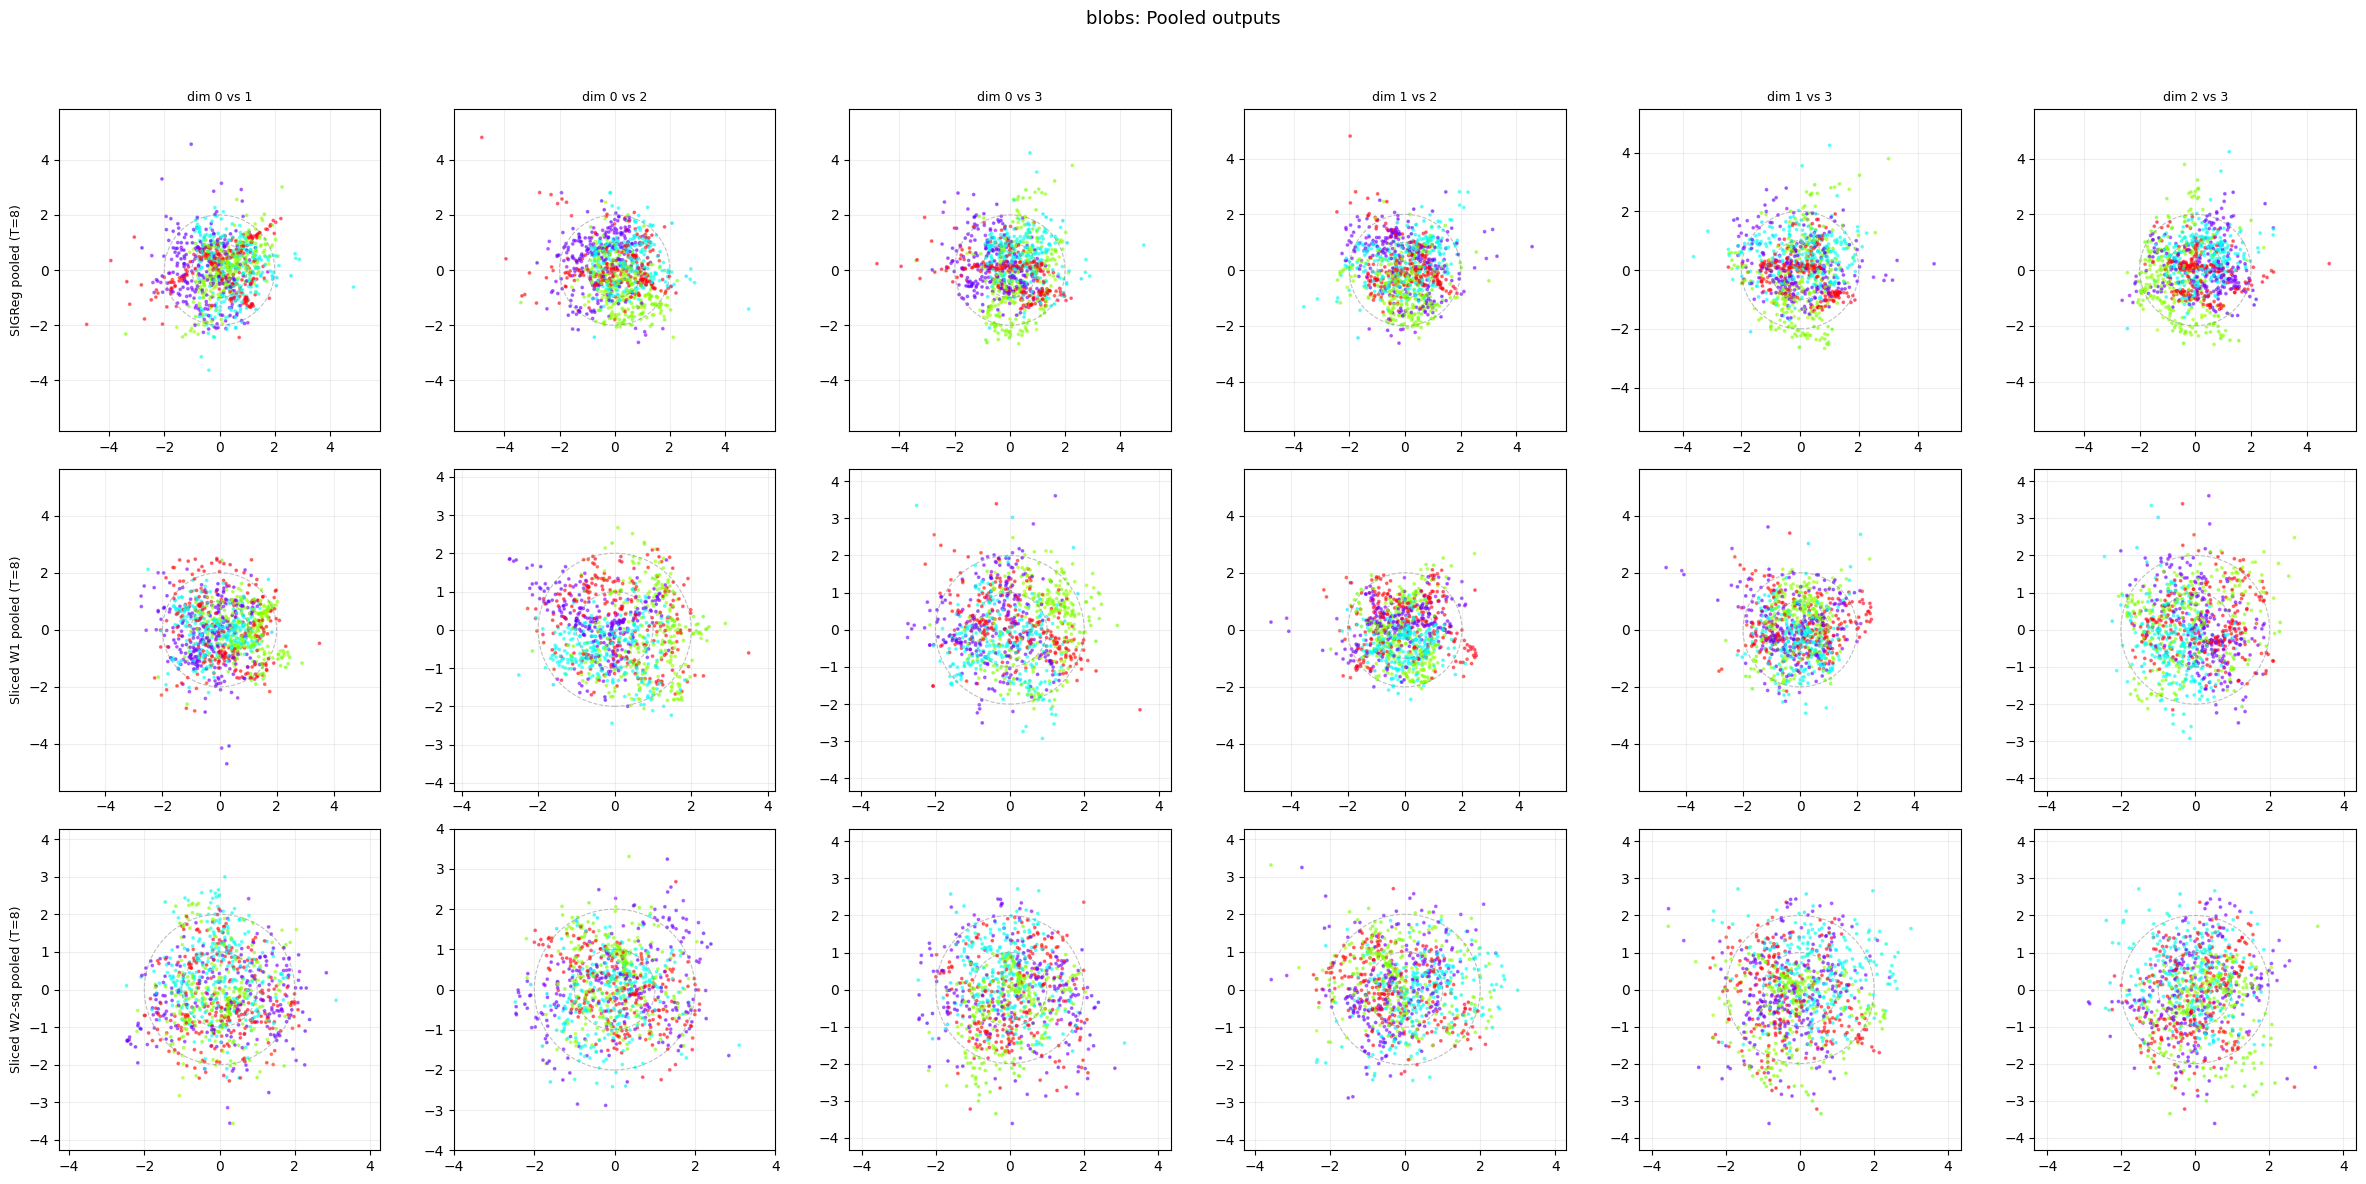

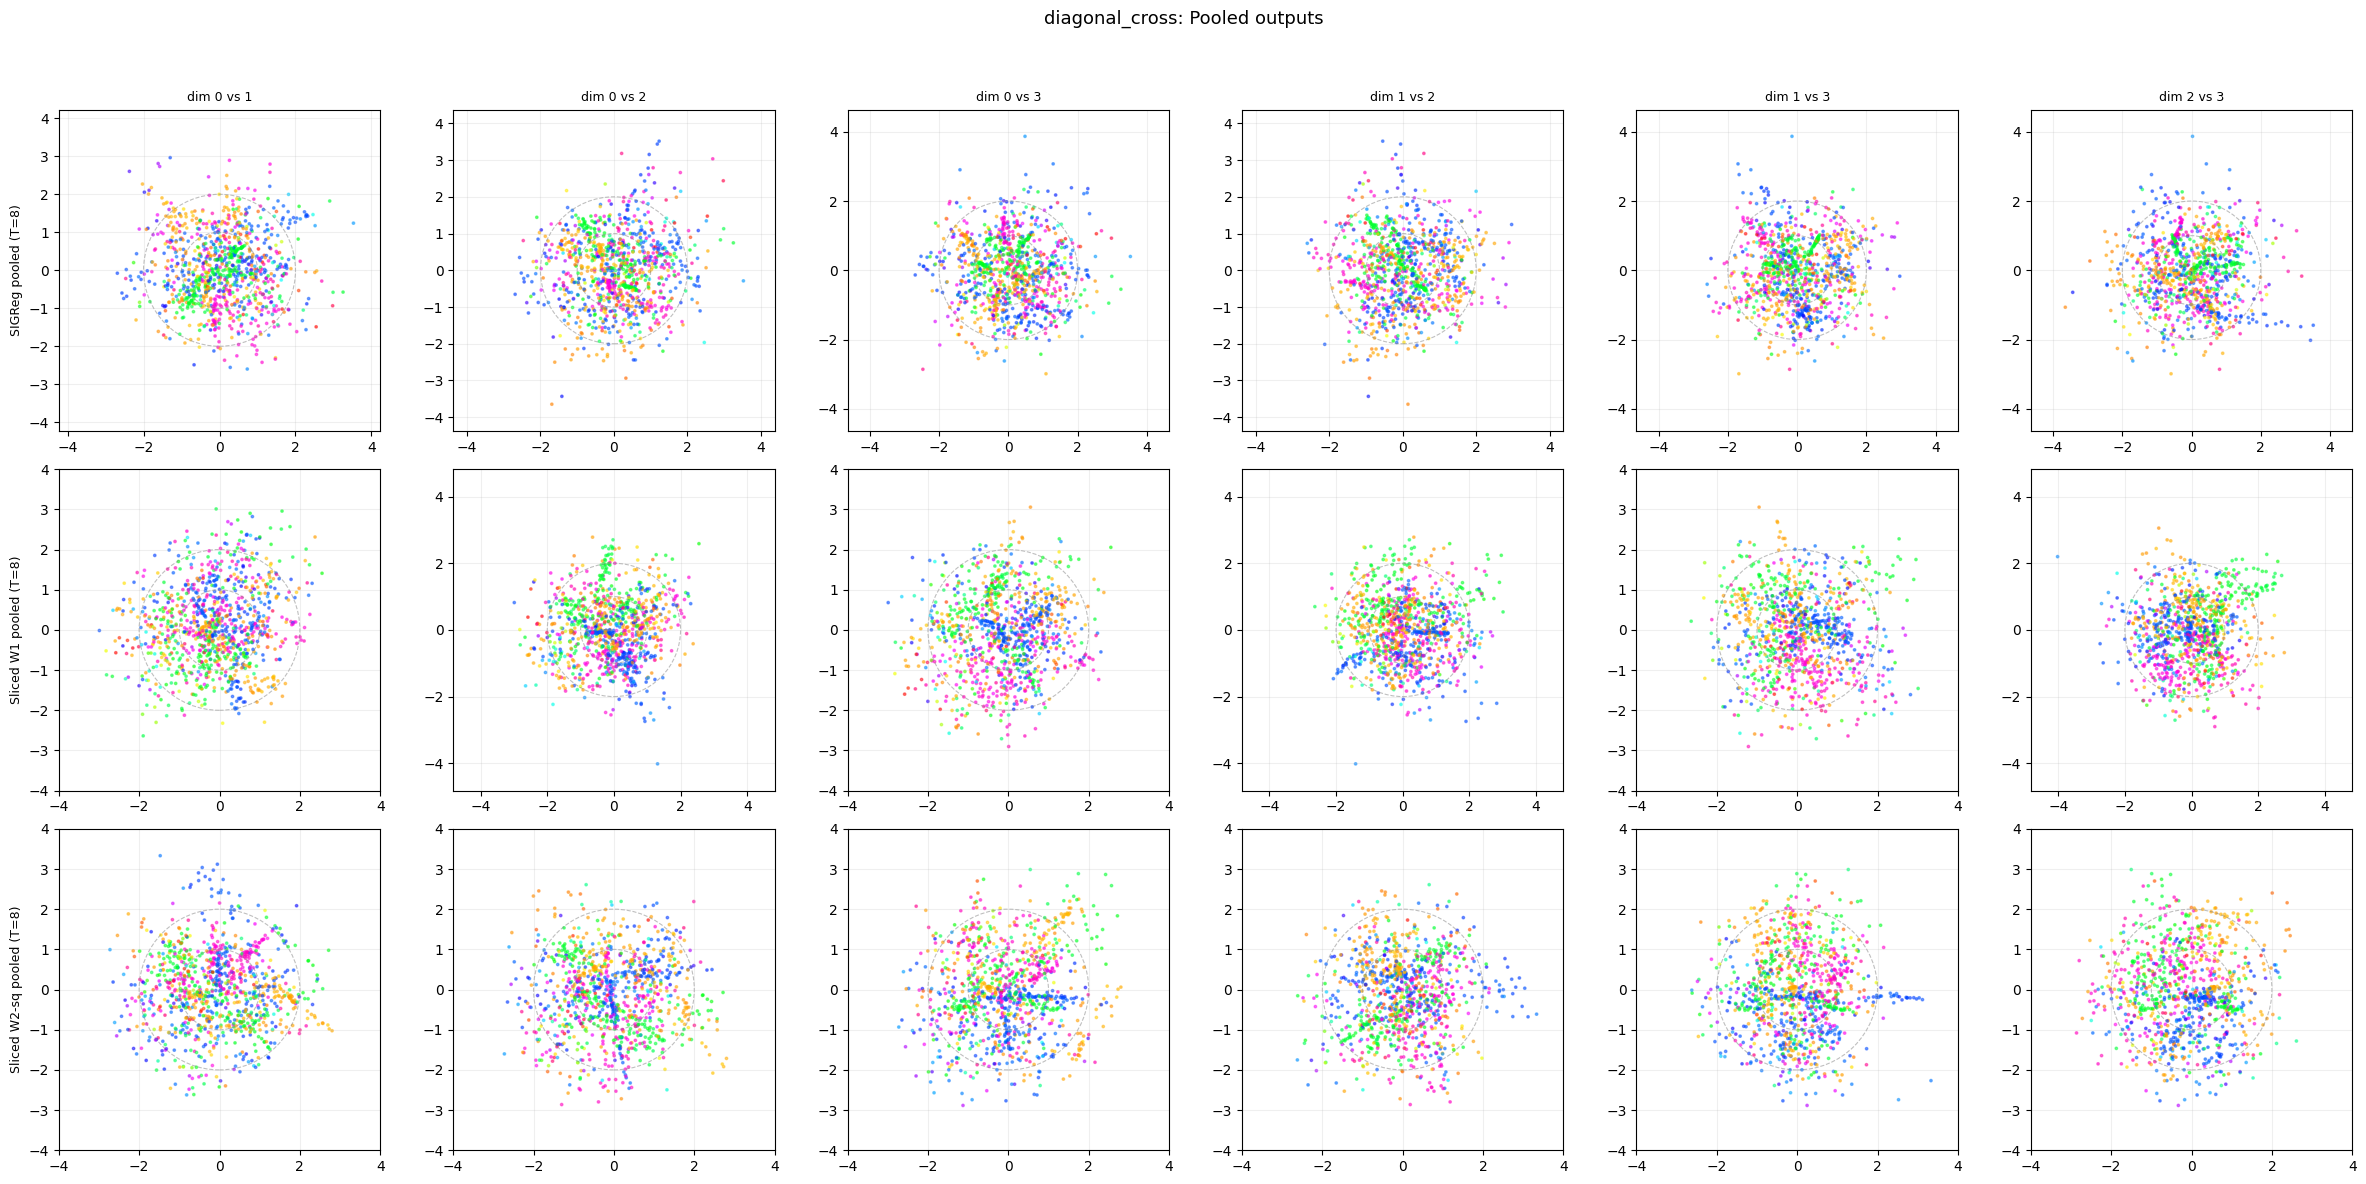

In [8]:
for dist_name in DISTRIBUTIONS:
    warmup_hist, results = all_results[dist_name]

    # Source data for coloring
    torch.manual_seed(42)
    data = generate_data(dist_name, K, D)
    src_np = data.numpy()
    angles = np.arctan2(src_np[:, 1] if D > 1 else np.zeros(K), src_np[:, 0])
    pt_colors = (angles + np.pi) / (2 * np.pi)

    # Initial output (from warmup checkpoint)
    W = make_fixed_projection(D, PROJ_DIM, seed=0).to(device)
    proj = data.to(device) @ W
    torch.manual_seed(123)
    mlp = DeepMLP(PROJ_DIM, 128, D, depth=2).to(device)
    # We don't have the checkpoint saved here, use first pooled method's final as proxy

    pooled_methods = [(l, f) for l, (h, f) in results.items() if 'pooled' in l]
    n_methods = len(pooled_methods)
    pairs = [(i, j) for i in range(min(D, 4)) for j in range(i + 1, min(D, 4))]
    n_cols = max(len(pairs), 1)

    fig, axes = plt.subplots(n_methods, n_cols, figsize=(4 * n_cols, 4 * n_methods))
    if n_methods == 1:
        axes = axes[np.newaxis, :]
    if n_cols == 1:
        axes = axes[:, np.newaxis]

    for row, (label, final) in enumerate(pooled_methods):
        for col, (di, dj) in enumerate(pairs):
            ax = axes[row, col]
            ax.scatter(final[:, di], final[:, dj], s=3, alpha=0.5,
                       c=pt_colors, cmap='hsv')
            for r in [1, 2]:
                ax.add_patch(plt.Circle((0, 0), r, fill=False, color='grey',
                                        linestyle='--', linewidth=0.8, alpha=0.5))
            ax.set_aspect('equal')
            lim = max(4, np.abs(final[:, [di, dj]]).max() * 1.2)
            ax.set_xlim(-lim, lim)
            ax.set_ylim(-lim, lim)
            ax.grid(alpha=0.2)
            if row == 0:
                ax.set_title(f'dim {di} vs {dj}', fontsize=9)
            if col == 0:
                ax.set_ylabel(label, fontsize=9)

    fig.suptitle(f'{dist_name}: Pooled outputs', fontsize=13)
    fig.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()